# **Jupyter notebook to plot 1D MESA models vs 2D ESTER models**

## **Step 1:** Copy this jupyter notebook to your google drive. Go to the menubar on the top, then select 'File' -> 'Save a copy in Drive'. Open the copy of the Jupyter notebook and follow the steps below.


## **Note:** To run the code below do 'shift + enter' in each cell.

## **Step 2:** Import the required python modules

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

##**Step 3:** Look in the folder 'dataforplots' in the minilab1 directory (there should be 4 files). This files contain the data for plotting the 2D ESTER models and a MESA model computed without rotation which you will use to compare with your MESA models.

##**Step 4:** Add all the 4 files to the google colab. To do so, click on the folder widget on the menubar on the left part of the screen. Then drag the 4 files into the current folder (more specifically to the 'content' folder).

##**Step 5:** Load the 4 files.

In [ ]:
## load the files inside the folder 'dataforplots' (NO NEED to modify any code here!!)

## load non-rotating MESA models for comparison
Mesa_norot  = np.genfromtxt("history_norotation.data", dtype=np.double,skip_header=6)
Mesa_norot = Mesa_norot.T

## load the 2D Ester files
dEster_06 = np.genfromtxt('2DEstermodel_10M_Omega06.txt', dtype=np.double,skip_header=1)
dEster_06 = dEster_06.T
dEster_075 = np.genfromtxt('2DEstermodel_10M_Omega075.txt', dtype=np.double,skip_header=1)
dEster_075 = dEster_075.T
dEster_09 = np.genfromtxt('2DEstermodel_10M_Omega09.txt', dtype=np.double,skip_header=1)
dEster_09 = dEster_09.T

## **Step 6:** Add the 'history.data' file from your runs in Exercise 2 to the same google colab folder.

## **Step 7:** Load your 'history.data' file.
## *   Modify the code below: modify the name of the file you are importing to match your history.data;
## *   Rename the 'label_run1' according to the physics included in your MESA models

In [ ]:
Mesa_run1  = np.genfromtxt('history_0.6_DSI.data', dtype=np.double,skip_header=6) ## MODIFY THE NAME OF THE FILE HERE
Mesa_run1 = Mesa_run1.T
label_run1 = 'MESA: $\Omega/\Omega_{crit}=60$%, DSI' ## MODIFY THE LABEL OF THE RUN HERE

## uncomment the 3 lines below to include a second MESA model
#Mesa_run2  = np.genfromtxt('history_0.75_DSI.data', dtype=np.double,skip_header=6)
#Mesa_run2 = Mesa_run2.T
#label_run2 = 'MESA: $\Omega/\Omega_{crit}=75%, DSI'


## **Step 8:** Plot the rotation evolution: MESA vs 2D Ester models. Run the cell below.

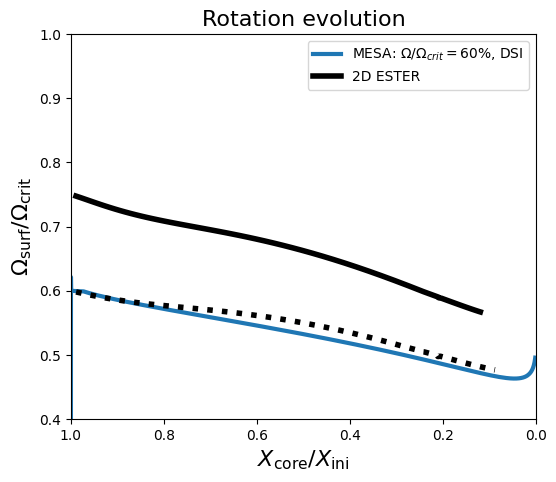

In [ ]:
fig1, (ax1) = plt.subplots(1,1, sharex=False,figsize=(6,5))

ax1.plot(Mesa_run1[53]/Mesa_run1[53][0], Mesa_run1[42],lw=3,c='tab:blue',label=label_run1)
#ax1.plot(Mesa_run2[53]/Mesa_run2[53][0], Mesa_run2[42],lw=3,c='tab:orange',label=label_run2) ## uncomment the line below to include a second MESA model

## plot the 2D Ester tracks
plt.plot(dEster_06[0],dEster_06[1],c='black',ls='dotted',lw=4) ## omega/omega_crit = 0.6
plt.plot(dEster_075[0],dEster_075[1],c='black',label='2D ESTER',lw=4) ## omega/omega_crit = 0.75
#plt.plot(dEster_09[0],dEster_09[1],c='black',ls='dashed',lw=4) ## omega/omega_crit = 0.9

## ploting settings
ax1.set_xlabel(r'$X_{\mathrm{core}}/X_{\mathrm{ini}}$',fontsize=16)
ax1.set_ylabel(r'$\Omega_{\mathrm{surf}}/\Omega_{\mathrm{crit}}$',fontsize=16)
ax1.set_xlim([1,0])
ax1.set_ylim([0.4,1])

ax1.legend()
plt.title('Rotation evolution',fontsize=16)
plt.savefig('rotation_evolution.png')

##**Step 9:** Plot the diferential rotation in the MESA models. Run the cell below.

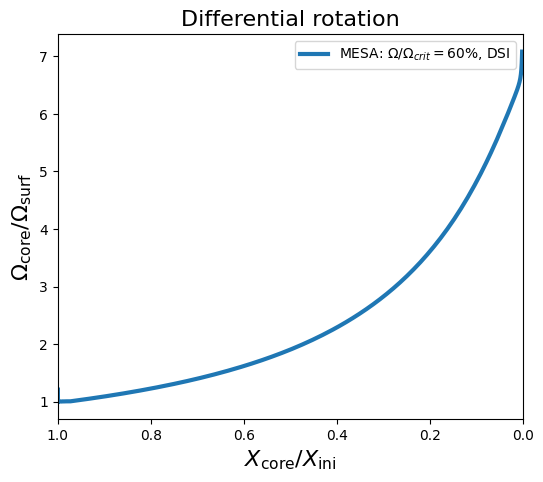

In [ ]:
fig1, (ax1) = plt.subplots(1,1, sharex=False,figsize=(6,5))

ax1.plot(Mesa_run1[53]/Mesa_run1[53][0], Mesa_run1[65],lw=3,label=label_run1,c='tab:blue')
#ax1.plot(Mesa_run2[53]/Mesa_run2[53][0], Mesa_run2[65],lw=3,label=label_run2,c='tab:orange') ## uncomment the line below to include a second MESA model

## plotting settings
ax1.set_xlabel(r'$X_{\mathrm{core}}/X_{\mathrm{ini}}$',fontsize=16)
ax1.set_ylabel(r'$\Omega_{\mathrm{core}}/\Omega_{\mathrm{surf}}$',fontsize=16)
ax1.set_xlim([1,0])
ax1.legend()
plt.title('Differential rotation',fontsize=16)
plt.savefig('differential_rotation.png')

## **Step 10:** Plot the HR diagram with Gravity Darkening. Run the cell below.

/tmp/ipython-input-75-627442908.py:27: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(np.log10(Mesa_run1[46]), np.log10(Mesa_run1[45]),ls='dotted',c='tab:orange',lw=3) # plot the equatorial HRD
/tmp/ipython-input-75-627442908.py:28: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(np.log10(Mesa_run1[44]), np.log10(Mesa_run1[43]),ls='dashed',c='tab:orange',lw=3) # plot the polar HRD
/tmp/ipython-input-75-627442908.py:36: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(np.log10(Mesa_norot[46][0]), np.log10(Mesa_norot[45][0]),ls='dotted',lw=3,c='grey',label='equatorial')
/tmp/ipython-input-75-627442908.py:37: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(np.log10(Mesa_norot[44][0]), np.log10(Mesa_norot[43][0]),ls='dashed',lw=3,c='grey',label='polar')


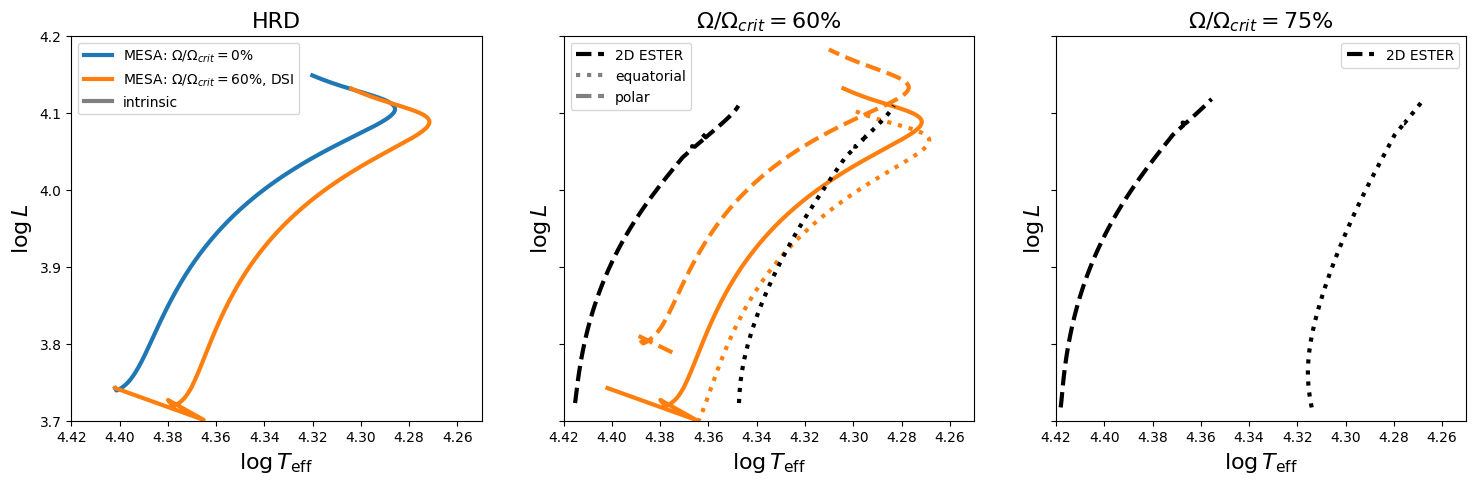

In [ ]:
plt.rcParams['savefig.dpi']=500
fig1, (ax1,ax2,ax3) = plt.subplots(1,3, sharex=True,sharey=True,figsize=(18,5))


## plot ax1: HR diagram -------------------------------------------------------------------------------------------------------------------------------------

 ## MESA model computed without rotation for comparison purposes
ax1.plot(Mesa_norot[36], Mesa_norot[37],lw=3,label=r'MESA: $\Omega/\Omega_{crit}=0$%')

 ## your MESA models
ax1.plot(Mesa_run1[36], Mesa_run1[37],c='tab:orange',lw=3,label=label_run1) # omega/omega_crit = 60%
#ax1.plot(Mesa_run2[36], Mesa_run2[37],c='tab:red',lw=3,label=label_run2) # omega/omega_crit = 75%  # uncomment the line below to include a second MESA model

 ## for legend purposes
ax1.set_title('HRD',fontsize=16)
ax1.plot(Mesa_norot[36][0], Mesa_norot[37][0],lw=3,c='grey',label='intrinsic')
ax1.set_xlabel(r'$\log T_{\mathrm{eff}}$',fontsize=16)
ax1.set_ylabel(r'$\log L$',fontsize=16)
ax1.set_xlim([4.42,4.25])
ax1.set_ylim([3.7,4.2])
ax1.legend()

## plot ax2: omega/omega_crit = 60% -------------------------------------------------------------------------------------------------------------------------------------

 ## your MESA model with omega/omega_crit = 60%
ax2.plot(Mesa_run1[36], Mesa_run1[37],c='tab:orange',lw=3) # plot the intrinsic variables of HRD
ax2.plot(np.log10(Mesa_run1[46]), np.log10(Mesa_run1[45]),ls='dotted',c='tab:orange',lw=3) # plot the equatorial HRD
ax2.plot(np.log10(Mesa_run1[44]), np.log10(Mesa_run1[43]),ls='dashed',c='tab:orange',lw=3) # plot the polar HRD

 ## plot the 2D Ester tracks for omega/omega_crit = 0.6
ax2.plot(dEster_06[2],dEster_06[4],c='black',ls='dashed',lw=3,label=r'2D ESTER') # plot the polar HRD
ax2.plot(dEster_06[3],dEster_06[4],c='black',ls='dotted',lw=3) # plot the equatorial HRD

 ## for legend purposes
ax2.set_title(label=r'$\Omega/\Omega_{crit}=60$%',fontsize=16)
ax2.plot(np.log10(Mesa_norot[46][0]), np.log10(Mesa_norot[45][0]),ls='dotted',lw=3,c='grey',label='equatorial')
ax2.plot(np.log10(Mesa_norot[44][0]), np.log10(Mesa_norot[43][0]),ls='dashed',lw=3,c='grey',label='polar')
ax2.set_xlabel(r'$\log T_{\mathrm{eff}}$',fontsize=16)
ax2.set_ylabel(r'$\log L$',fontsize=16)
ax2.legend()


## plot ax3 omega/omega_crit = 75% -------------------------------------------------------------------------------------------------------------------------------------

 ## your MESA model with omega/omega_crit = 75%
 ## uncomment the lines below to include a second MESA model
#ax3.plot(Mesa_run8[36], Mesa_run8[37],c='tab:red',lw=3)
#ax3.plot(np.log10(Mesa_run8[46]), np.log10(Mesa_run8[45]),ls='dotted',c='tab:red',lw=3) # plot the equatorial HRD
#ax3.plot(np.log10(Mesa_run8[44]), np.log10(Mesa_run8[43]),ls='dashed',c='tab:red',lw=3) # plot the polar HRD

 ## plot the 2D Ester tracks for omega/omega_crit = 0.75
ax3.plot(dEster_075[2],dEster_075[4],c='black',ls='dashed',label='2D ESTER',lw=3)
ax3.plot(dEster_075[3],dEster_075[4],c='black',ls='dotted',lw=3) # plot the equatorial HRD

 ## for legend purposes
ax3.set_title(label=r'$\Omega/\Omega_{crit}=75$%',fontsize=16)
ax3.set_xlabel(r'$\log T_{\mathrm{eff}}$',fontsize=16)
ax3.set_ylabel(r'$\log L$',fontsize=16)
ax3.legend()

plt.savefig('HRD.png')
#plt.close()
